In [73]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.ticker as ticker
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter,
                               AutoMinorLocator)
plt.rcParams.update({'font.size': 12})
#import seaborn as sns
import cmath
import math 
from numpy.linalg import inv
def custom_plot_single(fig, ax1, 
                       x_lst, y_lst, label_lst, xlim, ylim, label,pltname,
                       color=['k','r','b','g','o','c','m','y','gray'],
                       linestyle=['solid','dashed','solid','dashed','solid','dashed'],
                       markertype=[None,None,'o','^','o','^'],
                       fillstyle=['none','none','none','none','full','full'],
                       linewidth=20*[3],
                       markevery=[450,30,50,40,56,72,63,95],
                       show_legend=True,
                       plt_outside=False, y_logscale = False, x_logscale=False):
    
    fig.patch.set_facecolor('white')
    ax1.patch.set_facecolor('white')
    #color[len(x_lst)-1] = 'gray'
    for p in range(0, len(x_lst)):
        ax1.plot(x_lst[p], y_lst[p], color[p],
                 linewidth=linewidth[p],
                 linestyle=linestyle[p],
                 marker=markertype[p],
                 fillstyle=fillstyle[p],
                 markevery=markevery[p],
                 markersize=8,
                 label=label_lst[p])
    if(show_legend):
        ax1.legend(prop={'size': 20},loc='best')
    ax1.tick_params(which='minor', width=2, length=4, color='k')
    ax1.tick_params(which='major', width=2, length=8, color='k')

    #ax1.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    #ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    if(show_legend):
        ax1.legend(prop={'size': 20},loc='best',shadow=True)
    if (y_logscale):
        ax1.set_yscale('log')
    if (x_logscale):
        ax1.set_xscale('log')
        
    if ylim is not None:
        ax1.set_ylim(ylim[0], ylim[1])
    
    if xlim is not None:
        ax1.set_xlim(xlim[0], xlim[1])

    ax1.set_xlabel(label[0], fontsize=25)#, fontdict=dict(weight='bold'))
    ax1.set_ylabel(label[1], fontsize=25)#, fontdict=dict(weight='bold'))
    fontsize=15
    for tick in ax1.xaxis.get_major_ticks():
        tick.label1.set_fontsize(fontsize)

    for tick in ax1.yaxis.get_major_ticks():
        tick.label1.set_fontsize(fontsize)
    if(plt_outside==False):
        plt.savefig(pltname, bbox_inches = "tight")
    return plt,pltname

PrintFigures=True
PointCharge=True

In [74]:
main_path = '../../../Exec/atomic_chain/negf/atomic_chain'
dos_path  = main_path+'/DOS_step'

num_steps = 1 #new iterations
h_eV_per_Hz = 4.13566769e-15
hbar_eV_per_Hz = 6.582119569e-16
dos_pts = 1000
num_atoms=3
Er     =  np.zeros((num_steps,dos_pts),dtype=float)
Fermi1 = np.zeros((num_steps, dos_pts),dtype=float)
Fermi2 = np.zeros((num_steps, dos_pts),dtype=float)
DOSr   = np.zeros((num_steps, dos_pts),dtype=float)
Tr     = np.zeros((num_steps, dos_pts),dtype=float)
Gr     = np.zeros((num_steps, dos_pts),dtype=float)

In [75]:
# Loop through each step
for f in range(num_steps):
    # Construct the file path
    file_path = dos_path + f"{f:04d}/transport_char.dat"
    
    # Use 'with' statement to automatically close the file
    with open(file_path) as fileTransportChar:
        # Skip the first line and read the next `dos_pts` lines
        lines = [line.split() for i, line in enumerate(fileTransportChar) if 0 < i <= dos_pts]
    
    # Convert the lines to a numpy array (2D array with dtype=float)
    data = np.array(lines, dtype=float)
    
    # Extract the columns
    Er[f] = data[:, 0]
    Fermi1[f] = data[:, 1]
    Fermi2[f] = data[:, 2]
    DOSr[f] = data[:, 3]
    Tr[f] = data[:, 4]
    Gr[f] = data[:, 5]
    
    # Optional: print or log intermediate results for debugging
    # print('Er', Er[f])
    # print('Fermi1', Fermi1[f])    


In [76]:
i=0
j=0
step_size=1

In [77]:
Er_scaled = np.sqrt(Er)/1e13
x_label = r'$\omega$ / (10$^{13}$rad.sec$^{-1}$)'

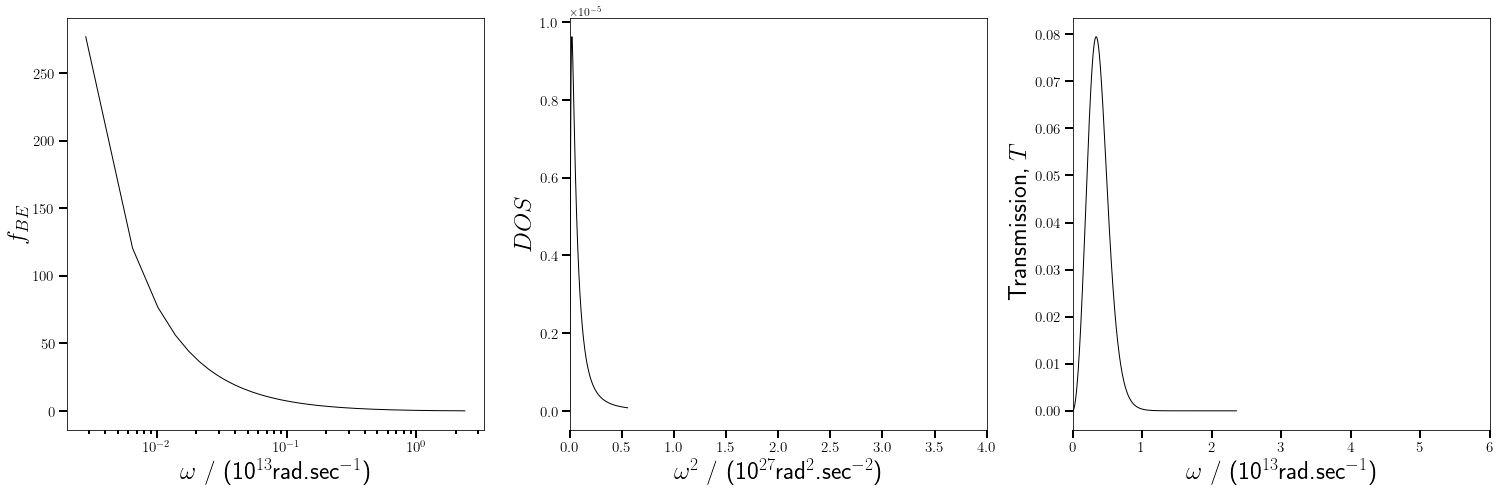

In [78]:
fig, ax = plt.subplots(1,3)
fig.set_size_inches(21,7)
#fig.suptitle(r'$V_{ds}=%.1f~$V, Rings= %d'%(Vds, pts), fontsize=30)
if(PrintFigures):
    plt1,pltname = custom_plot_single(fig, ax[0],
                                     [Er_scaled[x] for x in range(i,j+1,step_size)],                                       
                                     [Fermi1[x] for x in range(i,j+1,step_size)],                                      
                                     [None for x in range(i,j+1,step_size)],
                                     None, 
                                     None, 
                                     [x_label,
                                      r'$f_{BE}$'],
                                     'Q_zoom.png',
                                     linestyle=['solid']*(j-i+1),
                                     fillstyle=['none']*(j-i+1),
                                     linewidth=[1]*(j-i+1),
                                     markevery=[1]*(j-i+1),
                                     markertype=[None]*(j-i+1),
                       show_legend=False,
                       plt_outside=True, y_logscale=False, x_logscale=True)

    
    plt1,pltname = custom_plot_single(fig, ax[1],
                                     [Er[x]/1e27 for x in range(i,j+1,step_size)],                                       
                                     [DOSr[x] for x in range(i,j+1,step_size)],                                      
                                     [None for x in range(i,j+1,step_size)],
                                     [0,4], 
                                     None, 
                                     [r'$\omega^2$ / (10$^{27}$rad$^2$.sec$^{-2}$)',
                                      r'$DOS$'],
                                     'Q_zoom.png',
                                     linestyle=['solid']*(j-i+1),
                                     fillstyle=['none']*(j-i+1),
                                     linewidth=[1]*(j-i+1),
                                     markevery=[1]*(j-i+1),
                                     markertype=[None]*(j-i+1),
                       show_legend=False,
                       plt_outside=True, y_logscale=False, x_logscale=False)

    plt1,pltname = custom_plot_single(fig, ax[2],
                                     [Er_scaled[x] for x in range(i,j+1,step_size)],                                       
                                     [Tr[x] for x in range(i,j+1,step_size)],                                      
                                     [None for x in range(i,j+1,step_size)],
                                     [0,6], 
                                     None, 
                                     [x_label,
                                      r'Transmission, $T$'],
                                     'Q_zoom.png',
                                     linestyle=['solid']*(j-i+1),
                                     fillstyle=['none']*(j-i+1),
                                     linewidth=[1]*(j-i+1),
                                     markevery=[1]*(j-i+1),
                                     markertype=[None]*(j-i+1),
                       show_legend=False,
                       plt_outside=True, y_logscale=False, x_logscale=False)

    # plt1,pltname = custom_plot_single(fig, ax[1][1],
    #                                  [Er_scaled[x] for x in range(i,j+1,step_size)],                                       
    #                                  [Gr[x] for x in range(i,j+1,step_size)],                                      
    #                                  [None for x in range(i,j+1,step_size)],
    #                                  None, 
    #                                  None, 
    #                                  [x_label,
    #                                   r'$G$'],
    #                                  'Q_zoom.png',
    #                                  linestyle=['solid']*(j-i+1),
    #                                  fillstyle=['none']*(j-i+1),
    #                                  linewidth=[1]*(j-i+1),
    #                                  markevery=[1]*(j-i+1),
    #                                  markertype=[None]*(j-i+1),
    #                    show_legend=False,
    #                    plt_outside=True, y_logscale=False)
fig.tight_layout()
fig.savefig(main_path + '_transport_char.png', dpi='figure', format='png', pad_inches=0.1, facecolor='auto', edgecolor='auto')

# DOS 2D

In [79]:
dos_iter=2
step=0
dos_step_folder =dos_path+"%04d"%(step)


num_Epts = dos_pts
spatial_pts = num_atoms

# percent_intercuts = np.array([30, 80])
# num_paths = np.size(percent_intercuts)
# print(num_paths)

DOS2D = np.zeros((num_Epts,spatial_pts),dtype=float)
PTD = np.zeros(num_Epts, dtype=float)
Evec = np.zeros(num_Epts, dtype=float)

for e in range(num_Epts):
    E_file = open(dos_step_folder+"/Ept_%d.dat"%(e))
    lst = []
    counter=0
    for line in E_file:    
        if (counter > 0):
            lst += [line.split()]
        counter  = counter + 1
    if(e==0):
        ptd = [x[0] for x in lst]
        PTD = np.asfarray(ptd)  #Angstrom
        dos2d = [x[1] for x in lst]
        DOS2D[e] = np.asfarray(dos2d)
    
OmegaSq = Er.reshape(-1)/1e27

In [80]:
from matplotlib import ticker, cm
from matplotlib import rc, rcParams
import matplotlib.colors as colors
rc('text', usetex=True)


ContourMin  0.0
ContourMax  2.07261226940607e-10
3 100
-0.55 0.55
x_lst [-0.55, 0.55]
y_lst [8.02106e-07, 0.013779399999999999]
[0.00000000e+00 2.30290252e-11 4.60580504e-11 6.90870756e-11
 9.21161009e-11 1.15145126e-10 1.38174151e-10 1.61203177e-10
 1.84232202e-10 2.07261227e-10]


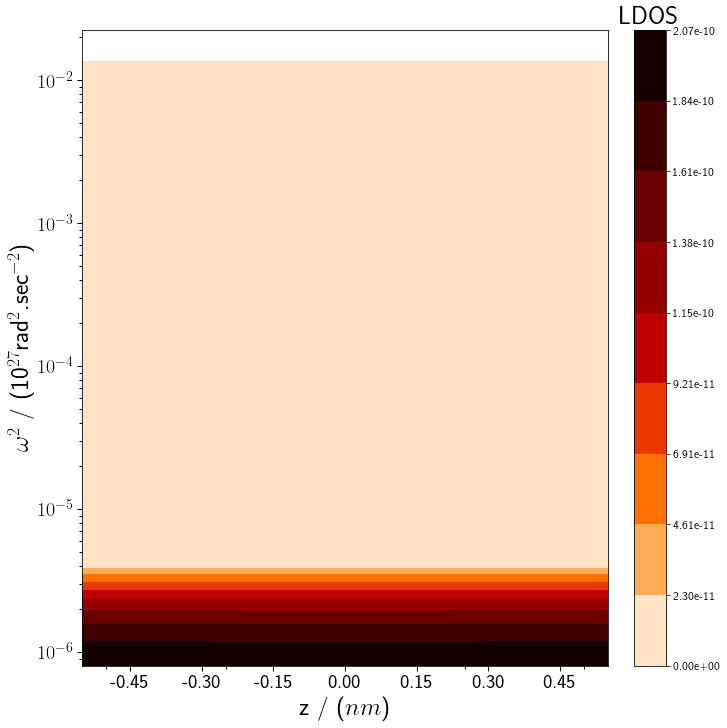

In [81]:
from matplotlib.ticker import MaxNLocator

def contour_DOS2D(contourdata, ContourMin, ContourMax, xarr, yarr, fig, ax, cbarTrue, cbarlabel,
                  x_lst, y_lst, color_lst):
    print(len(xarr), len(yarr))
    print(xarr[0], xarr[-1])
    print('x_lst', x_lst)
    print('y_lst', y_lst)

    X, Y = np.meshgrid(xarr, yarr)  

    cmap = plt.get_cmap('gist_heat_r')
    levels_exp = np.linspace(ContourMin, ContourMax, 10)  # Logarithmic spacing for levels
    levels = levels_exp

    print(levels)
    extent = [xarr[0], xarr[-1], yarr[0], yarr[-1]]

    cpl = ax.contourf(X, Y, contourdata, extent=extent, levels=levels, cmap=cmap)

    x_lst = np.array(x_lst)
    y_lst = np.array(y_lst)

    for p in range(len(x_lst)):
        ax.plot(x_lst[p], y_lst[p], color_lst[p], linewidth=3, linestyle='solid')

    if cbarTrue:
        cbar = fig.colorbar(cpl, ax=ax, format='%.2e')
        cbar.ax.set_title(cbarlabel, fontsize=25, weight="bold")

    # Use MaxNLocator to limit the number of ticks
    ax.xaxis.set_major_locator(MaxNLocator(integer=True, prune='lower', nbins=10))
    ax.yaxis.set_major_locator(MaxNLocator(integer=True, prune='lower', nbins=10))

    # Optionally adjust minor ticks as needed
    ax.xaxis.set_minor_locator(MaxNLocator(integer=True, prune='lower', nbins=5))
    ax.yaxis.set_minor_locator(MaxNLocator(integer=True, prune='lower', nbins=5))

    # Format the tick labels
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

    ax.tick_params(which='minor', length=3, color='black', width=1)
    ax.tick_params(which='major', length=5, color='black', width=1)

    # Adjust the font size for ticks manually
    ax.tick_params(axis='x', labelsize=20)
    ax.tick_params(axis='y', labelsize=20)

    # Set the y-axis to logarithmic scale
    ax.set_yscale('log')

    # Set the x-axis to symmetric logarithmic scale
    #ax.set_xscale('symlog')

    return plt

# Set up your plot
fig, ax = plt.subplots(1, 1, constrained_layout=True)
fig.set_size_inches(10, 10)

minId = 0
#maxId = num_Epts - 1
maxId = 100
Evec_len = Evec[maxId] - Evec[0]

ContourMin = np.nanmin(DOS2D[minId:maxId])
ContourMax = np.nanmax(DOS2D[minId:maxId])
print('ContourMin ', ContourMin)
print('ContourMax ', ContourMax)

myplt1 = contour_DOS2D(
    DOS2D[minId:maxId], ContourMin, ContourMax,
    PTD, OmegaSq[minId:maxId], fig, ax, cbarTrue=True, cbarlabel=r'LDOS',
    x_lst=[PTD[0], PTD[-1]], 
    y_lst=[OmegaSq[minId], OmegaSq[maxId]],
    color_lst=['b', 'r']
)

ax.set_xlabel(r'z / ($nm$)', fontsize=25)
ax.set_ylabel(r'$\omega^2$ / (10$^{27}$rad$^2$.sec$^{-2}$)', fontsize=25)

plt.savefig(main_path + '_LDOS_%04d' % (dos_iter), dpi='figure', format='png', pad_inches=0.1, facecolor='white', edgecolor='auto')
